In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
# Прочитайте данные (переменную назовите 'df')
df = pd.read_csv('data.csv')

# Вывести несколько первых строк таблицы данных
print(df.head())

         Дата  Склад Контрагент Номенклатура  Количество
0  2018-01-04      1  address_0    product_0           4
1  2018-01-04      1  address_0    product_1           4
2  2018-01-04      1  address_0    product_2           5
3  2018-01-04      1  address_0    product_3          10
4  2018-01-04      1  address_0    product_4           2


Проверяем формат столбцов

In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 301355 entries, 0 to 301354
Data columns (total 5 columns):
 #   Column        Non-Null Count   Dtype 
---  ------        --------------   ----- 
 0   Дата          301355 non-null  object
 1   Склад         301355 non-null  int64 
 2   Контрагент    301355 non-null  object
 3   Номенклатура  301355 non-null  object
 4   Количество    301355 non-null  int64 
dtypes: int64(2), object(3)
memory usage: 11.5+ MB


Сразу переведем столбец "Дата" в правильный формат

In [4]:
df['Дата'] = pd.to_datetime(df['Дата'])
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 301355 entries, 0 to 301354
Data columns (total 5 columns):
 #   Column        Non-Null Count   Dtype         
---  ------        --------------   -----         
 0   Дата          301355 non-null  datetime64[ns]
 1   Склад         301355 non-null  int64         
 2   Контрагент    301355 non-null  object        
 3   Номенклатура  301355 non-null  object        
 4   Количество    301355 non-null  int64         
dtypes: datetime64[ns](1), int64(2), object(2)
memory usage: 11.5+ MB


Сгруппируйте данные по дате, посчитайте количество продаж

In [5]:
grouped_df = df.groupby('Дата')['Количество'].sum()

Вывести несколько первых строк сгруппированных данных

In [6]:
print(grouped_df.head())

Дата
2018-01-04    3734
2018-01-05    3643
2018-01-06    3193
2018-01-07    3298
2018-01-09    4055
Name: Количество, dtype: int64


Нарисуйте график продаж у `grouped_df`

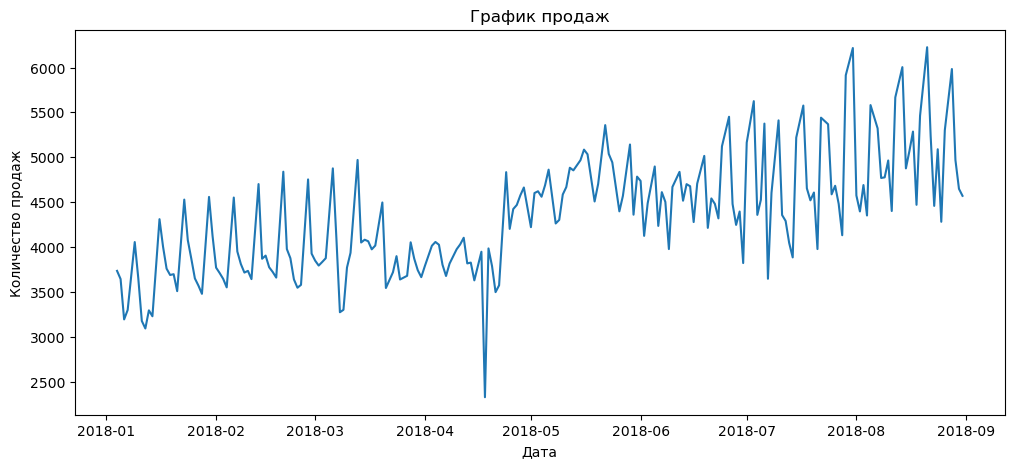

In [7]:
plt.figure(figsize=(12, 5))
plt.plot (grouped_df)
plt.title('График продаж')
plt.xlabel('Дата')
plt.ylabel('Количество продаж')
plt.show()

Опишите что вы видите на графике. Ваша задача - максимально описать график

Продажи сильно скачут изо дня в день, в течении 9 месяцев в среднем продаж составляют 4000-5000. В апреле-мае был провал меньше 2500 продаж. Ближе к концу августа график взлетел почти до пиковых 6500.

Найдите строку, у которой максимальный выброс по количеству продаж (нужно найти выброс у `df`)

In [8]:
df.sort_values(by='Количество', ascending=False).head(1)

,Дата,Склад,Контрагент,Номенклатура,Количество
218822,2018-06-28,1,address_208,product_0,200


Найдите топовый товар по продажам по средам за июнь, июль, август у 3 склада

In [9]:
# Фильтрую данные по складу №3, месяцам (июнь-август: 6, 7, 8) и среде (2)
filtered = df[
    (df['Склад'] == 3) & 
    (df['Дата'].dt.month >= 6) & 
    (df['Дата'].dt.month <= 8) & 
    (df['Дата'].dt.weekday == 2)
]
# Группирую по товарам и находим лидера
top_item = filtered.groupby('Номенклатура')['Количество'].sum().sort_values(ascending=False).head(1)
top_item

Номенклатура
product_1    2267
Name: Количество, dtype: int64

Скачайте данные по погоде с https://rp5.ru/Архив_погоды_в_Астане (скачайте исходные данные, и далее преобразуйте так, чтобы мы имели Дату и Среднюю температуру за день), объедините таблицу температуры с `grouped_df`, и нарисуйте график `y=['Количество продаж', 'T']`, где Т это температура. А также отдельно график температуры.

In [10]:
# 1. Читаю данные из скачанного файла и даю имя переменной weather_df, смотрю данные
weather_df = pd.read_csv('Погода Астана 04.01.2018-31.08.2018.csv', sep=';', skiprows=6, quotechar='"', dtype=str)
weather_df.head()

,Местное время в Астане,T,Po,P,Pa,U,DD,Ff,ff10,ff3,...,Cm,Ch,VV,Td,RRR,tR,E,Tg,E',sss
31.08.2018 23:00,8.2,736.6,768.3,0.2,78,"Ветер, дующий с северо-востока",4,NaN,NaN,70 – 80%.,...,"Перистых, перисто-кучевых или перисто-слоистых...",NaN,4.6,Следы осадков,12,NaN,NaN,NaN,NaN,NaN
31.08.2018 20:00,9.6,736.4,767.9,1.2,88,"Ветер, дующий с западо-северо-запада",3,NaN,NaN,"90 или более, но не 100%",...,"Перистых, перисто-кучевых или перисто-слоистых...",NaN,7.7,Следы осадков,12,NaN,NaN,NaN,NaN,NaN
31.08.2018 17:00,11.3,735.2,766.4,0.4,83,"Ветер, дующий с востоко-северо-востока",4,NaN,NaN,100%.,...,NaN,10.0,8.5,NaN,NaN,NaN,NaN,NaN,NaN,NaN
31.08.2018 14:00,12.3,734.8,765.9,0.9,80,"Ветер, дующий с северо-востока",4,NaN,NaN,100%.,...,NaN,4.0,8.9,NaN,NaN,NaN,NaN,NaN,NaN,NaN
31.08.2018 11:00,13.2,733.9,764.8,1.0,83,"Ветер, дующий с северо-северо-востока",4,NaN,NaN,100%.,...,NaN,10.0,10.3,3.0,12,NaN,NaN,NaN,NaN,NaN


In [11]:
# 2. Приводим данные в порядок:
# Cбрасываем индекс, чтобы даты вернулись в обычные столбцы
weather_df = weather_df.reset_index()

# Берем первые два столбца и сразу задаем им понятные имена
weather_df = weather_df.iloc[:, [0, 1]]
weather_df.columns = ['Дата', 'Т']

In [12]:
# 3. Проверяяю формат и количество столбцов
weather_df.info()
weather_df.head()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1918 entries, 0 to 1917
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype 
---  ------  --------------  ----- 
 0   Дата    1918 non-null   object
 1   Т       1918 non-null   object
dtypes: object(2)
memory usage: 30.1+ KB


,Дата,Т
0,31.08.2018 23:00,8.2
1,31.08.2018 20:00,9.6
2,31.08.2018 17:00,11.3
3,31.08.2018 14:00,12.3
4,31.08.2018 11:00,13.2


In [13]:
# 4. Перевожу столбцы в правильный формат
weather_df['Дата'] = pd.to_datetime(
    weather_df['Дата'], 
    format='%d.%m.%Y %H:%M', 
    errors='coerce'
)

weather_df['Т'] = pd.to_numeric(weather_df['Т'].astype(str).str.replace(',', '.'), errors='coerce')
weather_df.info()
weather_df.head()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1918 entries, 0 to 1917
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype         
---  ------  --------------  -----         
 0   Дата    1918 non-null   datetime64[ns]
 1   Т       1918 non-null   float64       
dtypes: datetime64[ns](1), float64(1)
memory usage: 30.1 KB


,Дата,Т
0,2018-08-31 23:00:00,8.2
1,2018-08-31 20:00:00,9.6
2,2018-08-31 17:00:00,11.3
3,2018-08-31 14:00:00,12.3
4,2018-08-31 11:00:00,13.2


In [14]:
# 5. Группирую по дням и считаем среднее
result_df = weather_df.groupby(weather_df['Дата'].dt.date)['Т'].mean().reset_index()

# Переименовываю получившиеся колонки
result_df.columns = ['Дата', 'Avg_Temp']

# Привожу колонку Дата к формату datetime
result_df['Дата'] = pd.to_datetime(result_df['Дата'])

# Результат
result_df.head()

,Дата,Avg_Temp
0,2018-01-04,-14.0750
1,2018-01-05,-16.8625
2,2018-01-06,-13.3000
3,2018-01-07,-12.7500
4,2018-01-08,-15.4125


In [15]:
grouped_df.head()

Дата
2018-01-04    3734
2018-01-05    3643
2018-01-06    3193
2018-01-07    3298
2018-01-09    4055
Name: Количество, dtype: int64

In [16]:
grouped_df = pd.merge(grouped_df, result_df, on='Дата', how='inner')
grouped_df.head()

,Дата,Количество,Avg_Temp
0,2018-01-04,3734,-14.0750
1,2018-01-05,3643,-16.8625
2,2018-01-06,3193,-13.3000
3,2018-01-07,3298,-12.7500
4,2018-01-09,4055,-6.2500


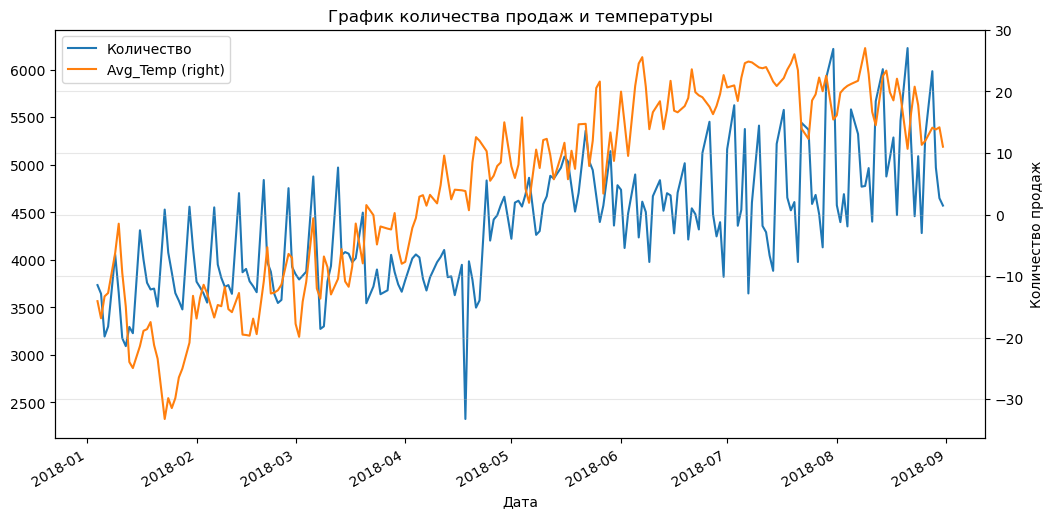

In [19]:
# Строю график продаж и температуры вместе (с двумя осями)
grouped_df.plot(x='Дата', y=['Количество', 'Avg_Temp'], figsize=(12, 6), secondary_y=['Avg_Temp'])
plt.title('График количества продаж и температуры')
plt.xlabel('Дата')
plt.ylabel('Количество продаж')
plt.grid(True, alpha=0.3)
plt.show()

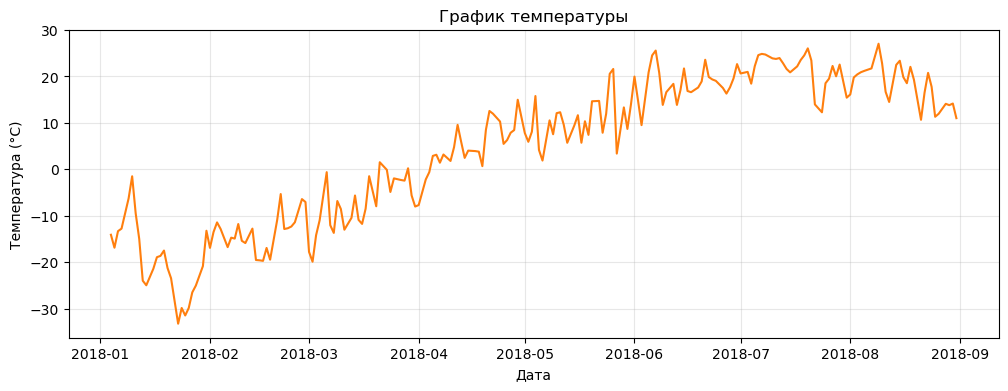

In [20]:
plt.figure(figsize=(12, 4))
plt.plot(grouped_df['Дата'], grouped_df['Avg_Temp'], color='tab:orange', linewidth=1.5)
plt.title('График температуры')
plt.xlabel('Дата')
plt.ylabel('Температура (°C)')
plt.grid(True, alpha=0.3)
plt.show()